# Tier 3 (C) — Whisper-small Encoder Training & Evaluation

**Prerequisite:** run `tier3_c_precompute.ipynb` first and attach its output
as the Kaggle Dataset `slavic-lid-whisper-mels`.
The mels are expected somewhere under `/kaggle/input/slavic-lid-whisper-mels/mels/`.

## What this notebook does
- Loads precomputed 80×300 float16 Whisper log-Mel arrays (no HF download, no feature extraction).
- Trains `WhisperLID` (whisper-small encoder + classification head) in two phases:
  Phase 1 — encoder frozen, head only (4 epochs).
  Phase 2 — full fine-tune (6 epochs, cosine LR).
- Uses `nn.DataParallel` across both T4 GPUs automatically.
- Evaluates on `test` (in-domain) and `eval_fleurs` (OOD), saves `results.json`.

**Accelerator:** GPU T4 x2 | **Internet:** on (for model download from HF Hub)


In [1]:
!pip uninstall -q -y torchvision
!pip install -q -U transformers huggingface_hub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 101.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
timm 1.0.26 requires torchvision, which is not installed.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.


In [2]:
import os, gc, glob, json, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from transformers import WhisperModel, WhisperFeatureExtractor
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
N_GPU   = torch.cuda.device_count() if DEVICE.type == "cuda" else 0
print(f"Device: {DEVICE} | n_gpu: {N_GPU} | AMP: {USE_AMP}")


Device: cuda | n_gpu: 2 | AMP: True


In [3]:
# ── HF auth (only needed for the model weights download, not the dataset) ──────
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient
try:
    login(token=UserSecretsClient().get_secret("HF_TOKEN"), add_to_git_credential=False)
    print("HF login OK")
except Exception as e:
    print(f"HF login skipped ({e})")


HF login OK


In [4]:
# ── Constants ──────────────────────────────────────────────────────────────────
WHISPER_ID       = "openai/whisper-small"
N_MELS           = 80
VALID_MEL_FRAMES = 300          # 3 s @ 10 ms hop
VALID_ENC_FRAMES = 150          # after Whisper's conv stride-2
LANGUAGES        = ["be", "bg", "cs", "mk", "pl", "ru", "sr", "uk"]
LANG2ID          = {l: i for i, l in enumerate(LANGUAGES)}
ID2LANG          = {i: l for i, l in enumerate(LANGUAGES)}
NUM_CLASSES      = len(LANGUAGES)

CKPT_DIR = "/kaggle/working/tier3_whisper"
os.makedirs(CKPT_DIR, exist_ok=True)


In [5]:
# ── Load precomputed mel shards ────────────────────────────────────────────────
# Searches recursively under /kaggle/input for shards produced by tier3_c_precompute.ipynb.
# Attach the 'slavic-lid-whisper-mels' dataset; shards land at
# /kaggle/input/slavic-lid-whisper-mels/mels/ (exact path depends on your dataset slug).

SPLIT_PREFIXES = {"train": "train_mel_f16", "test": "test_mel_f16", "eval_fleurs": "fleurs_mel_f16"}
EXPECTED_ROWS  = {"train": 80_000, "test": 107_439, "eval_fleurs": 6_157}
SHARD_SIZE     = 10_000

def _list_shards(prefix):
    paths = sorted(glob.glob(f"/kaggle/input/**/{prefix}_*.npz", recursive=True))
    assert paths, (
        f"No shards found for '{prefix}'. "
        f"Attach the 'slavic-lid-whisper-mels' dataset produced by tier3_c_precompute.ipynb."
    )
    return paths

def _load_shards(prefix, expected):
    paths = _list_shards(prefix)
    Xs, ys = [], []
    for p in paths:
        with np.load(p) as d:
            Xs.append(d["X"]); ys.append(d["y"])
    X = np.concatenate(Xs, axis=0); y = np.concatenate(ys, axis=0)
    assert len(y) == expected, f"{prefix}: got {len(y)} rows, expected {expected}"
    assert X.shape[1:] == (N_MELS, VALID_MEL_FRAMES), f"Unexpected mel shape: {X.shape}"
    return X, y

print("Loading mel shards...", flush=True)
X_train,  y_train  = _load_shards(SPLIT_PREFIXES["train"],       EXPECTED_ROWS["train"])
X_test,   y_test   = _load_shards(SPLIT_PREFIXES["test"],        EXPECTED_ROWS["test"])
X_fleurs, y_fleurs = _load_shards(SPLIT_PREFIXES["eval_fleurs"], EXPECTED_ROWS["eval_fleurs"])
gb = (X_train.nbytes + X_test.nbytes + X_fleurs.nbytes) / 1e9
print(f"Train {X_train.shape} | Test {X_test.shape} | FLEURS {X_fleurs.shape}  (~{gb:.1f} GB RAM)")


Loading mel shards...
Train (80000, 80, 300) | Test (107439, 80, 300) | FLEURS (6157, 80, 300)  (~9.3 GB RAM)


## Dataset & DataLoaders


In [6]:
class SlavicLIDDataset(Dataset):
    """Serves pre-extracted Whisper log-Mel (float16 on disk, cast to float32 on demand)."""
    def __init__(self, X, y):
        self.X = X; self.y = y
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx].astype(np.float32)), int(self.y[idx])


In [7]:
# With DataParallel across both T4s, dim-0 is split evenly: 64/GPU at BATCH_SIZE=128.
# Drop back to 64 (-> 32/GPU) if you hit VRAM OOM during fine-tuning.
BATCH_SIZE = 128 if N_GPU > 1 else 64

rng = np.random.default_rng(SEED)
small_idx = rng.choice(len(y_test), size=min(4_000, len(y_test)), replace=False)

train_dataset      = SlavicLIDDataset(X_train,           y_train)
test_small_dataset = SlavicLIDDataset(X_test[small_idx], y_test[small_idx])
test_full_dataset  = SlavicLIDDataset(X_test,            y_test)
fleurs_dataset     = SlavicLIDDataset(X_fleurs,          y_fleurs)

_kw = dict(num_workers=4, pin_memory=True, persistent_workers=True)
train_loader      = DataLoader(train_dataset,      batch_size=BATCH_SIZE, shuffle=True,  **_kw)
test_small_loader = DataLoader(test_small_dataset, batch_size=BATCH_SIZE, shuffle=False, **_kw)
test_full_loader  = DataLoader(test_full_dataset,  batch_size=BATCH_SIZE, shuffle=False, **_kw)
fleurs_loader     = DataLoader(fleurs_dataset,     batch_size=BATCH_SIZE, shuffle=False, **_kw)

print(f"Train {len(train_dataset):,}  |  Test-small {len(test_small_dataset):,}  |  "
      f"Test-full {len(test_full_dataset):,}  |  FLEURS {len(fleurs_dataset):,}  |  batch={BATCH_SIZE}")

# Quick sanity check
feat, lbl = train_dataset[42]
print(f"Sample shape: {tuple(feat.shape)}  label: {ID2LANG[lbl]}")


Train 80,000  |  Test-small 4,000  |  Test-full 107,439  |  FLEURS 6,157  |  batch=128
Sample shape: (80, 300)  label: be


## Model

`WhisperLID`: whisper-small encoder (patched to accept 3 s / 150-token sequences) with a two-layer
head (Linear 768→256 + ReLU + Dropout → Linear 256→8).

`autocast` lives **inside** `forward()` and `get_embeddings()` because `torch.amp.autocast` is
thread-local and `nn.DataParallel` runs replicas in separate threads — wrapping only the call site
on the main thread would silently disable AMP on all replicas.


In [8]:
class WhisperLID(nn.Module):
    def __init__(self, n_classes=NUM_CLASSES, whisper_id=WHISPER_ID, enc_frames=VALID_ENC_FRAMES):
        super().__init__()
        whisper = WhisperModel.from_pretrained(whisper_id)
        self.encoder = whisper.get_encoder()
        d_model = whisper.config.d_model  # 768 for whisper-small

        # Short-window patch: shrink positional table from 1500 to 150 (= 3 s of audio).
        self.encoder.config.max_source_positions = enc_frames
        if hasattr(self.encoder, "max_source_positions"):
            self.encoder.max_source_positions = enc_frames
        emb = self.encoder.embed_positions
        emb.weight = nn.Parameter(emb.weight.data[:enc_frames].clone())
        emb.num_embeddings = enc_frames

        self.embed      = nn.Sequential(nn.Linear(d_model, 256), nn.ReLU(inplace=True), nn.Dropout(0.3))
        self.classifier = nn.Linear(256, n_classes)
        self._use_amp   = USE_AMP

    def _pool(self, x):
        return self.encoder(x).last_hidden_state.mean(dim=1)   # (B, d_model)

    def forward(self, x):
        with autocast("cuda", enabled=self._use_amp, dtype=torch.float16):
            return self.classifier(self.embed(self._pool(x)))

    def get_embeddings(self, x):
        with autocast("cuda", enabled=self._use_amp, dtype=torch.float16):
            return self.embed(self._pool(x))

    def freeze_encoder(self):
        for p in self.encoder.parameters(): p.requires_grad = False

    def unfreeze_encoder(self):
        for p in self.encoder.parameters(): p.requires_grad = True


In [9]:
model = WhisperLID().to(DEVICE)

# DataParallel across both T4s — falls back cleanly to single GPU/CPU.
# DDP would be faster but requires a multi-process launch, which doesn't fit a notebook well.
if torch.cuda.device_count() > 1:
    print(f"Wrapping in nn.DataParallel across {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

# `core` is the unwrapped model — use it for freeze/unfreeze, optimizer param groups,
# get_embeddings, and state_dict. Forward passes go through `model` to use both GPUs.
core = model.module if isinstance(model, nn.DataParallel) else model

n_all   = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Params: total={n_all:,}  trainable={n_train:,}")

dummy = torch.zeros(2, N_MELS, VALID_MEL_FRAMES, device=DEVICE)
with torch.no_grad():
    print("Forward shape:    ", tuple(model(dummy).shape))
    print("Embedding shape:  ", tuple(core.get_embeddings(dummy).shape))


config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Wrapping in nn.DataParallel across 2 GPUs
Params: total=87,316,232  trainable=87,316,232
Forward shape:     (2, 8)
Embedding shape:   (2, 256)


## Training

10 epochs total (team convention):
- **Phase 1 (4 ep)** — encoder frozen, head-only, LR 1e-3.
- **Phase 2 (6 ep)** — full fine-tune, encoder LR 1e-5, head LR 1e-4, cosine schedule.


In [10]:
EPOCHS      = 10
HEAD_EPOCHS = 4
FT_EPOCHS   = EPOCHS - HEAD_EPOCHS
HEAD_LR     = 1e-3
ENCODER_LR  = 1e-5
HEAD_LR_FT  = 1e-4
WD          = 1e-4

criterion = nn.CrossEntropyLoss()
try:
    scaler = GradScaler("cuda", enabled=USE_AMP)
except TypeError:
    scaler = GradScaler(enabled=USE_AMP)


def run_epoch(model, loader, criterion, optimizer, scaler, train: bool):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for feats, labels in tqdm(loader, leave=False):
            feats  = feats.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            # autocast lives inside model.forward(); no outer scope needed.
            logits = model(feats)
            loss   = criterion(logits, labels)
            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer); scaler.update()
            bs = labels.size(0)
            total_loss += loss.item() * bs
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += bs
    return total_loss / total, correct / total


In [11]:
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

# ── Phase 1: head only ────────────────────────────────────────────────────────
core.freeze_encoder()
optimizer = torch.optim.AdamW(
    (p for p in model.parameters() if p.requires_grad), lr=HEAD_LR, weight_decay=WD)

print(f"Phase 1 — head only, encoder frozen ({HEAD_EPOCHS} epochs)", flush=True)
for epoch in range(1, HEAD_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_loader,      criterion, optimizer, scaler, True)
    te_loss, te_acc = run_epoch(model, test_small_loader, criterion, optimizer, scaler, False)
    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss);  history["test_acc"].append(te_acc)
    print(f"[head] ep {epoch:2d}/{EPOCHS}  train loss {tr_loss:.4f} acc {tr_acc:.3f}  "
          f"val loss {te_loss:.4f} acc {te_acc:.3f}  {time.time()-t0:.0f}s", flush=True)

# ── Phase 2: fine-tune all ────────────────────────────────────────────────────
core.unfreeze_encoder()
optimizer = torch.optim.AdamW([
    {"params": core.encoder.parameters(),                                           "lr": ENCODER_LR},
    {"params": list(core.embed.parameters()) + list(core.classifier.parameters()), "lr": HEAD_LR_FT},
], weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FT_EPOCHS)

print(f"\nPhase 2 — fine-tune all ({FT_EPOCHS} epochs)", flush=True)
for epoch in range(HEAD_EPOCHS + 1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_loader,      criterion, optimizer, scaler, True)
    te_loss, te_acc = run_epoch(model, test_small_loader, criterion, optimizer, scaler, False)
    scheduler.step()
    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss);  history["test_acc"].append(te_acc)
    print(f"[ft]   ep {epoch:2d}/{EPOCHS}  train loss {tr_loss:.4f} acc {tr_acc:.3f}  "
          f"val loss {te_loss:.4f} acc {te_acc:.3f}  {time.time()-t0:.0f}s", flush=True)


Phase 1 — head only, encoder frozen (4 epochs)


  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

[head] ep  1/10  train loss 0.6863 acc 0.758  val loss 0.7746 acc 0.710  141s


  0%|          | 0/625 [00:00<?, ?it/s]

...

  0%|          | 0/32 [00:00<?, ?it/s]

[ft]   ep  9/10  train loss 0.0022 acc 1.000  val loss 0.7895 acc 0.852  336s


  0%|          | 0/625 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

[ft]   ep 10/10  train loss 0.0014 acc 1.000  val loss 0.8146 acc 0.851  336s


In [12]:
# ── Save checkpoint (unwrapped state_dict — no "module." prefix) ──────────────
torch.save({
    "model_state": core.state_dict(),
    "history":     history,
    "hparams": {
        "backbone": WHISPER_ID, "feature": "whisper-logmel-80x300-3s",
        "epochs": EPOCHS, "head_epochs": HEAD_EPOCHS, "ft_epochs": FT_EPOCHS,
        "head_lr": HEAD_LR, "encoder_lr": ENCODER_LR, "head_lr_ft": HEAD_LR_FT,
        "batch": BATCH_SIZE, "amp": USE_AMP, "n_gpu": N_GPU, "seed": SEED,
    },
}, f"{CKPT_DIR}/whisper_lid_final.pt")
print(f"Checkpoint -> {CKPT_DIR}/whisper_lid_final.pt", flush=True)


Checkpoint -> /kaggle/working/tier3_whisper/whisper_lid_final.pt


## Learning curves

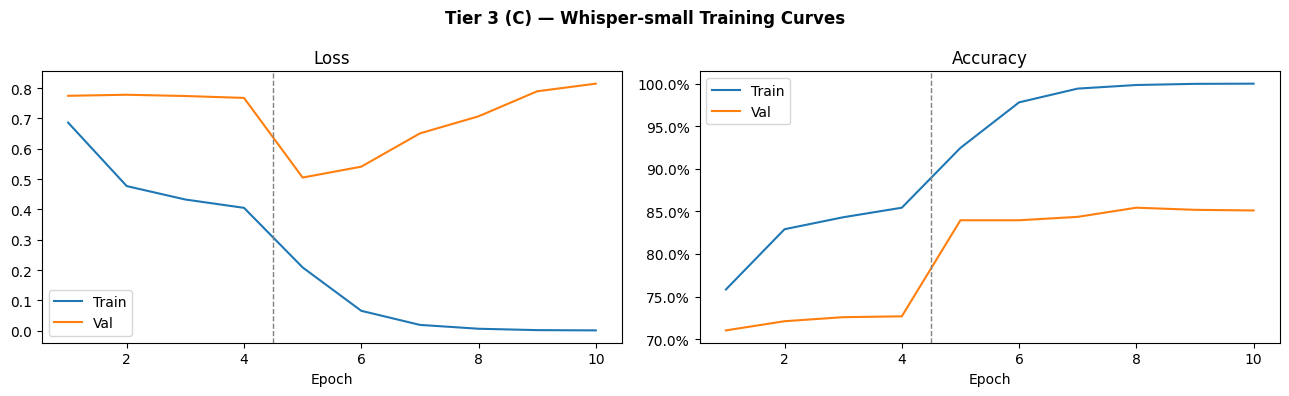

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, EPOCHS + 1)
ax1.plot(ep, history["train_loss"], label="Train"); ax1.plot(ep, history["test_loss"], label="Val")
ax1.axvline(HEAD_EPOCHS + 0.5, color="gray", ls="--", lw=1)
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(ep, history["train_acc"], label="Train"); ax2.plot(ep, history["test_acc"], label="Val")
ax2.axvline(HEAD_EPOCHS + 0.5, color="gray", ls="--", lw=1)
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.suptitle("Tier 3 (C) — Whisper-small Training Curves", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/learning_curves.png", dpi=150); plt.show()


## Evaluation — test & FLEURS

In [14]:
@torch.no_grad()
def evaluate(loader, collect_emb=False, desc="Eval"):
    model.eval()
    preds, labels, embs = [], [], []
    for feats, y in tqdm(loader, desc=desc):
        feats = feats.to(DEVICE, non_blocking=True)
        emb    = core.get_embeddings(feats).float()   # fp16 -> fp32 (classifier weights are fp32)
        logits = core.classifier(emb)
        preds.extend(logits.argmax(1).cpu().tolist())
        labels.extend(y.tolist())
        if collect_emb:
            embs.append(emb.cpu().numpy())
    p, l = np.array(preds), np.array(labels)
    return p, l, (np.concatenate(embs) if collect_emb else None)


all_preds, all_labels, all_emb = evaluate(test_full_loader, collect_emb=True, desc="Test")
overall_acc = (all_preds == all_labels).mean()
macro_f1    = f1_score(all_labels, all_preds, average="macro")
print(f"\n[TEST]  acc={overall_acc:.4f} ({overall_acc*100:.2f}%)  macro-F1={macro_f1:.4f}  (random=12.5%)")
print(classification_report(all_labels, all_preds, target_names=LANGUAGES, digits=3))


Test:   0%|          | 0/840 [00:00<?, ?it/s]


[TEST]  acc=0.8481 (84.81%)  macro-F1=0.7954  (random=12.5%)
              precision    recall  f1-score   support

          be      0.833     0.928     0.878     29232
          bg      0.909     0.598     0.722      6318
          cs      0.912     0.903     0.908     14441
          mk      0.674     0.793     0.728      3263
          pl      0.903     0.873     0.888     16949
          ru      0.838     0.876     0.857     19069
          sr      0.546     0.676     0.604      1666
          uk      0.843     0.724     0.779     16501

    accuracy                          0.848    107439
   macro avg      0.807     0.797     0.795    107439
weighted avg      0.852     0.848     0.847    107439



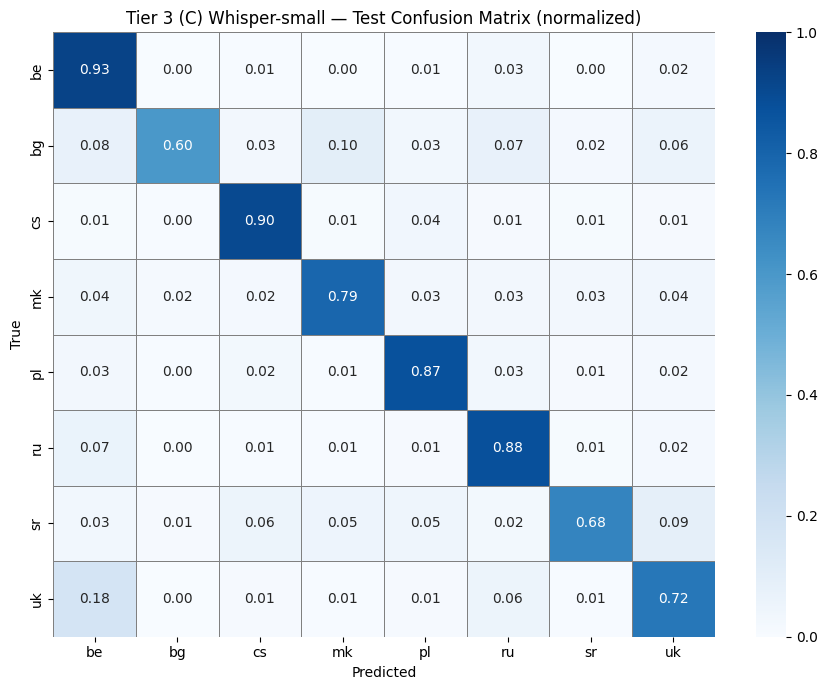

In [15]:
cm = confusion_matrix(all_labels, all_preds, normalize="true")
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=LANGUAGES, yticklabels=LANGUAGES, ax=ax,
            linewidths=0.5, linecolor="gray", vmin=0, vmax=1)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Tier 3 (C) Whisper-small — Test Confusion Matrix (normalized)")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/confusion_matrix_test.png", dpi=150); plt.show()


FLEURS:   0%|          | 0/49 [00:00<?, ?it/s]


[FLEURS]  acc=0.8215  macro-F1=0.8166
  vs Test: acc -0.0266  macro-F1 +0.0212
              precision    recall  f1-score   support

          be      0.805     0.869     0.836       967
          bg      0.902     0.738     0.812       511
          cs      0.855     0.658     0.744       723
          mk      0.869     0.869     0.869       973
          pl      0.750     0.939     0.834       758
          ru      0.823     0.792     0.807       775
          sr      0.858     0.749     0.799       700
          uk      0.778     0.892     0.831       750

    accuracy                          0.822      6157
   macro avg      0.830     0.813     0.817      6157
weighted avg      0.827     0.822     0.820      6157



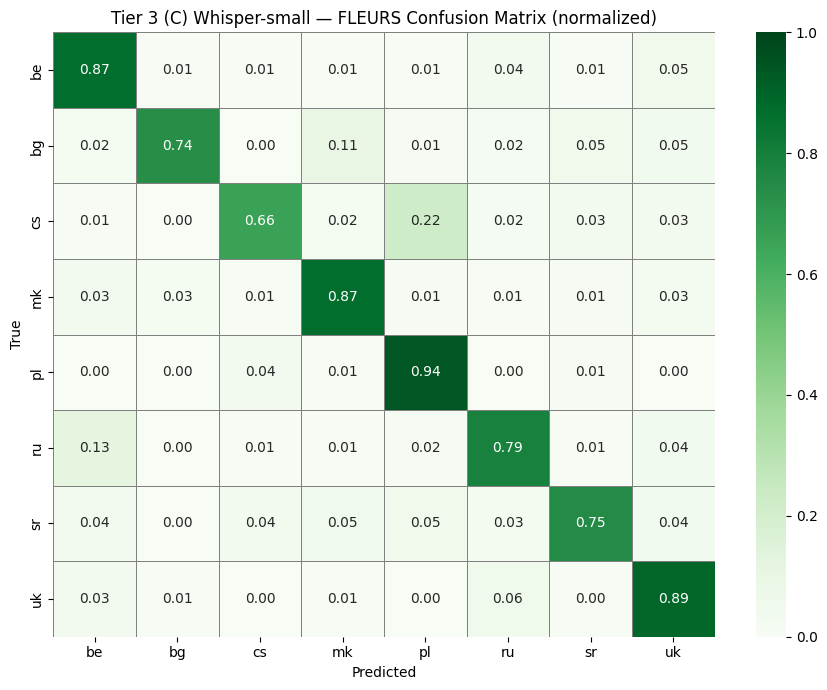

In [16]:
fl_preds, fl_labels, _ = evaluate(fleurs_loader, desc="FLEURS")
fl_acc      = (fl_preds == fl_labels).mean()
fl_macro_f1 = f1_score(fl_labels, fl_preds, average="macro")
print(f"\n[FLEURS]  acc={fl_acc:.4f}  macro-F1={fl_macro_f1:.4f}")
print(f"  vs Test: acc {fl_acc-overall_acc:+.4f}  macro-F1 {fl_macro_f1-macro_f1:+.4f}")
print(classification_report(fl_labels, fl_preds, target_names=LANGUAGES, digits=3))

cm_fl = confusion_matrix(fl_labels, fl_preds, normalize="true")
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_fl, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=LANGUAGES, yticklabels=LANGUAGES, ax=ax,
            linewidths=0.5, linecolor="gray", vmin=0, vmax=1)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Tier 3 (C) Whisper-small — FLEURS Confusion Matrix (normalized)")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/confusion_matrix_fleurs.png", dpi=150); plt.show()


## t-SNE of learned embeddings (balanced)

Per-language counts: {'be': 29232, 'bg': 6318, 'cs': 14441, 'mk': 3263, 'pl': 16949, 'ru': 19069, 'sr': 1666, 'uk': 16501}
Stratified t-SNE: 1600 samples/language -> 12800 total
Fitting t-SNE (perplexity=40)...


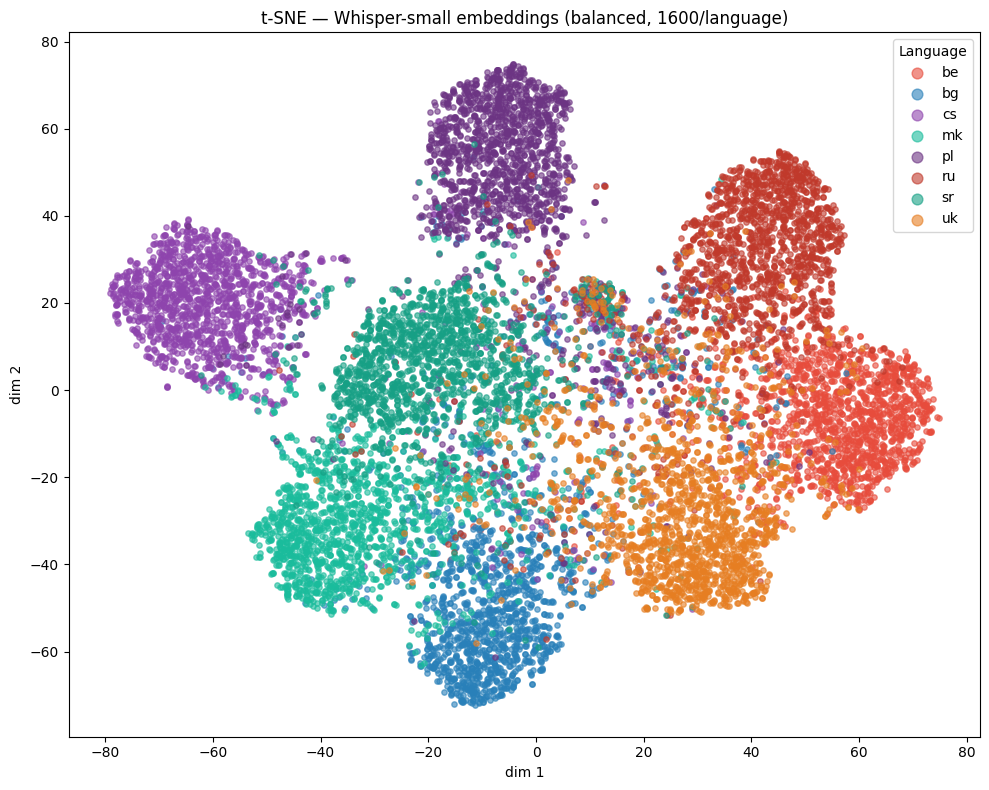

In [17]:
counts   = np.bincount(all_labels, minlength=len(LANGUAGES))
per_lang = min(int(counts.min()), 1600)
print(f"Per-language counts: {dict(zip(LANGUAGES, counts.tolist()))}")
print(f"Stratified t-SNE: {per_lang} samples/language -> {per_lang * len(LANGUAGES)} total")

tsne_rng = np.random.default_rng(SEED)
sel = np.concatenate([
    tsne_rng.choice(np.where(all_labels == c)[0], size=per_lang, replace=False)
    for c in range(len(LANGUAGES))
])
tsne_rng.shuffle(sel)

perplexity = min(40, max(5, (len(sel) - 1) // 3))
print(f"Fitting t-SNE (perplexity={perplexity})...", flush=True)
Z = TSNE(n_components=2, perplexity=perplexity, random_state=SEED, init="pca").fit_transform(all_emb[sel])

COLORS = {"be": "#e74c3c", "ru": "#c0392b", "uk": "#e67e22",
          "bg": "#2980b9", "mk": "#1abc9c", "sr": "#16a085",
          "cs": "#8e44ad", "pl": "#6c3483"}
fig, ax = plt.subplots(figsize=(10, 8))
for i, lang in enumerate(LANGUAGES):
    m = all_labels[sel] == i
    ax.scatter(Z[m, 0], Z[m, 1], label=lang, color=COLORS[lang], alpha=0.6, s=15)
ax.legend(title="Language", fontsize=10, markerscale=2)
ax.set_title(f"t-SNE — Whisper-small embeddings (balanced, {per_lang}/language)")
ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
plt.tight_layout()
plt.savefig(f"{CKPT_DIR}/tsne.png", dpi=150); plt.show()


## Save `results.json` (team convention)

In [18]:
def metrics_block(labels, preds):
    rep = classification_report(labels, preds, target_names=LANGUAGES, digits=4, output_dict=True)
    return {
        "overall_accuracy": float((preds == labels).mean()),
        "macro_f1":         float(f1_score(labels, preds, average="macro")),
        "per_language":     {l: rep[l] for l in LANGUAGES},
        "macro_avg":        rep["macro avg"],
        "weighted_avg":     rep["weighted avg"],
        "confusion_matrix": confusion_matrix(labels, preds).tolist(),
    }

results = {
    "tier": 3, "person": "C",
    "model": "whisper-small encoder + classification head",
    "backbone": WHISPER_ID, "feature": "whisper log-mel 80x300 (3 s window)",
    "seed": SEED, "epochs": EPOCHS, "head_epochs": HEAD_EPOCHS, "finetune_epochs": FT_EPOCHS,
    "languages": LANGUAGES, "history": history,
    "test": metrics_block(all_labels, all_preds),
    "eval_fleurs": metrics_block(fl_labels, fl_preds),
}
with open(f"{CKPT_DIR}/results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved {CKPT_DIR}/results.json")


Saved /kaggle/working/tier3_whisper/results.json
